#Introducción

En esta actividad se comparan dos enfoques de clasificación supervisada: Linear Discriminant Analysis (LDA) y árboles de decisión, los cuales parten de supuestos y estructuras diferentes. Mientras LDA construye fronteras lineales bajo supuestos probabilísticos sobre la distribución de las clases, los árboles de decisión generan particiones jerárquicas sin asumir linealidad. El objetivo es analizar el comportamiento geométrico y el desempeño predictivo de ambos modelos sobre el mismo conjunto de datos, para determinar cuál resulta más adecuado para el problema planteado.

En este caso de utilizara una base de datos relacionada a los exoplanetas, con el fin de clasificar si estos son habitables o no basado en variables dentro del dataset.

Tomaremos como referencia la temperatura de equilibrio `pl_eqt` de estos planetas, si se asemejan a la temperatura de equilibrio de la tierra **255 K**, o se encuentran en el rango de **250 - 300 K**, podemos considerarlos habitables.

## Metodología

- Definición de la variable de salida con dos o tres clases.

- Análisis del balance entre clases.

- División del dataset en entrenamiento y prueba, conservando la proporción de clases.

- Construcción del modelo LDA, seleccionando variables acordes a sus supuestos.

- Visualización e interpretación de las funciones discriminantes y la separación entre clases.

- Construcción del modelo de árbol de decisión con selección y justificación de parámetros.

- Aplicación de poda mediante el parámetro α para controlar la complejidad.

- Evaluación de ambos modelos con métricas de desempeño.

- Comparación e interpretación crítica de resultados cuantitativos y geométricos.

In [1]:
#Cargar datos
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Inteligencia_Artificial_1/dataset_final_exoplanetas.csv")

In [2]:
df.head(10)

,pl_name,pl_eqt,pl_insol,st_teff,st_rad
0,11 Com b,1700.0,792.57818,4060.0,1.313160
1,11 UMi b,1450.0,372.74340,3100.0,0.840000
2,14 And b,1600.0,513.74032,3530.0,0.366450
3,14 Her b,2369.0,427.54252,2943.0,0.289776
4,16 Cyg B b,2677.0,5262.59620,7244.6,1.976258
5,17 Sco b,2506.0,335.96392,3021.0,0.600455
6,18 Del b,1250.0,169.58952,2825.0,0.218870
7,1RXS J160929.1-210524 b,1616.0,513.74032,3592.0,0.672832
8,24 Boo b,1600.0,468.74252,3352.0,0.437589
9,24 Sex b,700.0,151.06598,7295.0,1.487260


> Nota: la base de datos utilizada, ya se ha utilizado en tareas y proyectos anteriores, con la finalidad de no tener que buscar multiples bases de datos para cada tarea, se va a trabajar con esta base de datos, la cual ya esta limpia e imputada.

### Crear variable binaria de habitabilidad

Como en este dataset tenemos mas que nada numeros, como antes comentamos, tomaremos en cuenta la temperatura de equilibrio del planeta para clasificarlo como habitable o no, de modo que crearemos una columna Habitability la cual tendra, `1` si cae en el rango de [250 - 300] Kelvin y si no cae dentro del rango, sera `0`, es decir, no habitable

In [3]:
# Crear variable binaria usando operaciones vectorizadas
df["Habitability"] = ((df["pl_eqt"] >= 250) & (df["pl_eqt"] <= 300)).astype(int)

# Verificar distribución
print(df["Habitability"].value_counts())

Habitability
0    4488
1      78
Name: count, dtype: int64


### Balance / Desbalance de clases

Con lo anterior podemos ver que claramente hay un desbalance de clases, por muchosimo mas, ya que al parecer tenemos 4488 planetas NO habitables y 78 planetas habitables, de modo que tendremos una proporcion muy pequeña de planetas habitables

### Calcular proporción


In [7]:
# Proporciones
print(df["Habitability"].value_counts(normalize=True) * 100)

Habitability
0    98.291721
1     1.708279
Name: proportion, dtype: float64


>IMPORTANTE: Bastante pequeña la proporción de planetas habitables, esto podria representar un problema ya que el modelo podria siempre predecir planetas que NO son habitables y confundir los pocos casos que si lo sean, de modo que podria ser necesario revisar precisión, F1 , matriz de confusión, entre otros.

### Dividir datos

En este caso, como tenemos un desbalance en las clases, vamos a utilizar el comando stratify, de esa forma aseguramos que los datos de train y test tengan la misma proporción en medida de lo posible.

In [10]:
from sklearn.model_selection import train_test_split

# Variables predictoras (X)
X = df.select_dtypes(include=["int64", "float64"]).drop(columns=["Habitability"])

# Variable objetivo (y)
y = df["Habitability"]

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,   # 🔥 mantiene proporción de clases
    random_state=42
)

# Verificar balance en cada subconjunto
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
Habitability
0    98.279099
1     1.720901
Name: proportion, dtype: float64

Test:
Habitability
0    98.321168
1     1.678832
Name: proportion, dtype: float64


### Modelo LDA

Ya que tenemos nuestros datos preparados, crearemos un modelo de Linear Discriminant Analysis y veremos su comportamiento

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear modelo
lda = LinearDiscriminantAnalysis()

# Entrenar
lda.fit(X_train, y_train)

# Predicciones
y_pred = lda.predict(X_test)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9817518248175182

Matriz de Confusión:
[[1345    2]
 [  23    0]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1347
           1       0.00      0.00      0.00        23

    accuracy                           0.98      1370
   macro avg       0.49      0.50      0.50      1370
weighted avg       0.97      0.98      0.97      1370



###Ver funciones discriminantes y coeficientes
Con el fin de poder comprender un poco mas como se comporta nuestro modelo, veamos la funcion disciminante y los coeficientes que tenemos

In [13]:
import pandas as pd

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": lda.coef_[0]
})

coef_df = coef_df.sort_values(by="Coeficiente", key=abs, ascending=False)

print(coef_df)

   Variable  Coeficiente
3    st_rad     0.393032
0    pl_eqt    -0.003944
1  pl_insol     0.000692
2   st_teff    -0.000613


### Visualizar la función discriminante


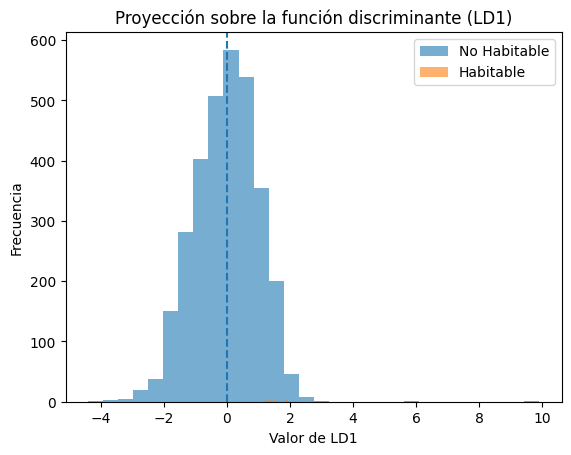

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Proyección en LD1
X_train_lda = lda.transform(X_train)

plt.figure()
plt.hist(X_train_lda[y_train==0], bins=30, alpha=0.6, label="No Habitable")
plt.hist(X_train_lda[y_train==1], bins=30, alpha=0.6, label="Habitable")

plt.axvline(0, linestyle="--")  # aproximación frontera
plt.legend()
plt.title("Proyección sobre la función discriminante (LD1)")
plt.xlabel("Valor de LD1")
plt.ylabel("Frecuencia")
plt.show()

La proyección de los datos sobre la función discriminante (LD1) muestra que ambas clases presentan una alta superposición. La distribución correspondiente a los planetas no habitables domina casi por completo el espacio, mientras que los pocos planetas clasificados como habitables quedan prácticamente contenidos dentro de esa misma distribución.

En términos geométricos, esto indica que la frontera lineal construida por LDA no logra separar claramente ambas clases, lo cual explica directamente el resultado obtenido en las métricas: el modelo no identifica correctamente ningún planeta habitable (recall = 0).

En cuanto a los coeficientes de la función discriminante, se observa que las variables con mayor influencia son el radio estelar (st_rad) y la insolación planetaria (pl_insol), que contribuyen positivamente a la clasificación como habitable, mientras que la temperatura de equilibrio (pl_eqt) y la temperatura efectiva estelar (st_teff) presentan contribuciones negativas.

Dado que la variable objetivo fue construida a partir de un rango específico de pl_eqt, resulta lógico que el modelo intente capturar indirectamente esa información a través de variables físicamente relacionadas, como la insolación y las propiedades de la estrella. Sin embargo, debido al fuerte desbalance entre clases y a la limitada separación lineal existente en los datos, el modelo no consigue discriminar adecuadamente los casos positivos.

# Modelo de arboles de decisión

Bien, ya vimos que al parecer con LDA, el modelo tiene muchos problemas para predecir la habitabilidad de los planetas, esto muy relacionado al fuerte desbalance de las clases.

Debido a esto, podemos probar un tipo diferente de modelo, en este caso utilizaremos arboles de desición, para ver si empeora o mejora.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear modelo base
tree = DecisionTreeClassifier(
    random_state=42
)

# Entrenar
tree.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree.predict(X_test)

> Nota: se definió una semilla para el random state

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9992700729927008

Matriz de Confusión:
[[1346    1]
 [   0   23]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1347
           1       0.96      1.00      0.98        23

    accuracy                           1.00      1370
   macro avg       0.98      1.00      0.99      1370
weighted avg       1.00      1.00      1.00      1370



> Nota: aqui podemos ver claramente que el modelo esta sobre ajustado ya que tenemos 100% de recall, F1 score y precisión.

Posiblemente esto haga que nuestros datos de test tengan resultados muy malos.

Una opción podria ser la poda de arboles, donde probemos distintos valores de alpha y ver cual se adecua mas a nuestro contexto. Basicamente probaremos valores de alpha hasta encontrar el mas optimo.

In [17]:
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [18]:
trees = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)
    trees.append(clf)

In [19]:
import numpy as np

test_scores = [clf.score(X_test, y_test) for clf in trees]

# Mejor alpha
best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Mejor alpha:", best_alpha)

Mejor alpha: 0.0


Aqui puede parecer que el mejor alpha haya dado 0, podria indicarnos que el arbol completo que tenemos desde un principio funciona mejor que las podas que hemos echo.

In [21]:
final_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

final_tree.fit(X_train, y_train)

y_pred_final = final_tree.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1347
           1       0.96      1.00      0.98        23

    accuracy                           1.00      1370
   macro avg       0.98      1.00      0.99      1370
weighted avg       1.00      1.00      1.00      1370



Visualización de arbol de decisión

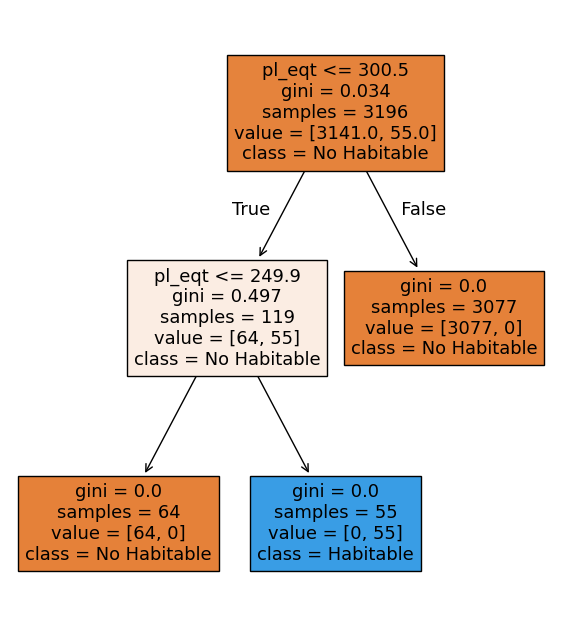

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(7,8))
plot_tree(
    final_tree,
    feature_names=X_train.columns,
    class_names=["No Habitable", "Habitable"],
    filled=True
)
plt.show()

Vemos aqui claramente que el arbol es en escencia muy pequeño, de modo que es natural pensar que funcione mejor sin poda que con ella.

### Importante
 el árbol de decisión identifica inmediatamente la temperatura de equilibrio (pl_eqt) como la variable más relevante, utilizándola en el nodo raíz. Las divisiones posteriores reconstruyen prácticamente el mismo intervalo empleado para definir la variable de salida, generando nodos puros con impureza nula (gini = 0). Esto indica que el modelo reproduce exactamente la regla de clasificación utilizada den rango de temperatura para construir la variable objetivo.

# Evaluación y Comparación de los Modelos

## Métricas de desempeño

Las métricas fueron calculadas sobre el conjunto de prueba utilizando accuracy, precisión, recall, F1-score y matriz de confusión.

El modelo **LDA** obtuvo una exactitud de 98.17%; sin embargo, no logró identificar ningún planeta habitable (recall = 0 para la clase 1). Esto indica que, aunque clasifica correctamente la mayoría de los casos, falla completamente en detectar la clase minoritaria.

El **árbol de decisión**, al incluir la variable `pl_eqt`, logró una separación prácticamente perfecta, generando nodos puros (gini = 0) y reproduciendo el intervalo de temperatura utilizado para definir la habitabilidad.

---

## Coherencia entre visualización y métricas

En LDA, la proyección sobre la función discriminante mostró una fuerte superposición entre clases, lo cual explica el bajo desempeño en la detección de planetas habitables. La ausencia de separación geométrica se refleja directamente en las métricas.

En el árbol de decisión, la estructura basada en umbrales sobre `pl_eqt` mostró una separación clara y consistente con el alto desempeño observado.

---

## Influencia de los supuestos

LDA asume normalidad, igualdad de covarianzas y una frontera lineal. Estas condiciones limitan su capacidad para capturar reglas basadas en intervalos, especialmente bajo fuerte desbalance de clases.

El árbol de decisión no requiere supuestos de distribución y puede modelar fácilmente reglas tipo “si-entonces”, lo que lo hace más adecuado para este tipo de problema.

---

## Ventajas y limitaciones

**LDA**
- Modelo estable y con interpretación geométrica clara.
- Sensible al desbalance y a la no linealidad.

**Árbol de decisión**
- Alta interpretabilidad mediante reglas explícitas.
- Capaz de capturar umbrales directamente.
- Puede sobreajustarse si no se controla su complejidad.

---

## Conclusión

Para este problema específico, el árbol de decisión resulta más adecuado al capturar correctamente la regla de clasificación basada en temperatura. No obstante, su desempeño debe interpretarse considerando que utiliza directamente la variable con la cual se definió la clase objetivo.

El modelo LDA, aunque presenta alta exactitud global, demuestra limitaciones importantes en la detección de la clase minoritaria.